# Runs Test for Randomness

The **runs test** (Wald-Wolfowitz) checks whether a sequence of observations is random. A *run* is a consecutive sequence of values all above or all below the median. Too few or too many runs signal non-randomness.

| Property | Value |
|---|---|
| **H₀** | Sequence is random (no trend, cycle, or autocorrelation) |
| **H₁** | Sequence is non-random |
| **Statistic** | Number of runs R |
| **Expected runs** | E[R] = 2n₁n₂/(n₁+n₂) + 1 |
| **Variance** | Var[R] = 2n₁n₂(2n₁n₂−n)/(n²(n−1)) |
| **z-score** | z = (R − E[R]) / √Var[R] → Normal for large n |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

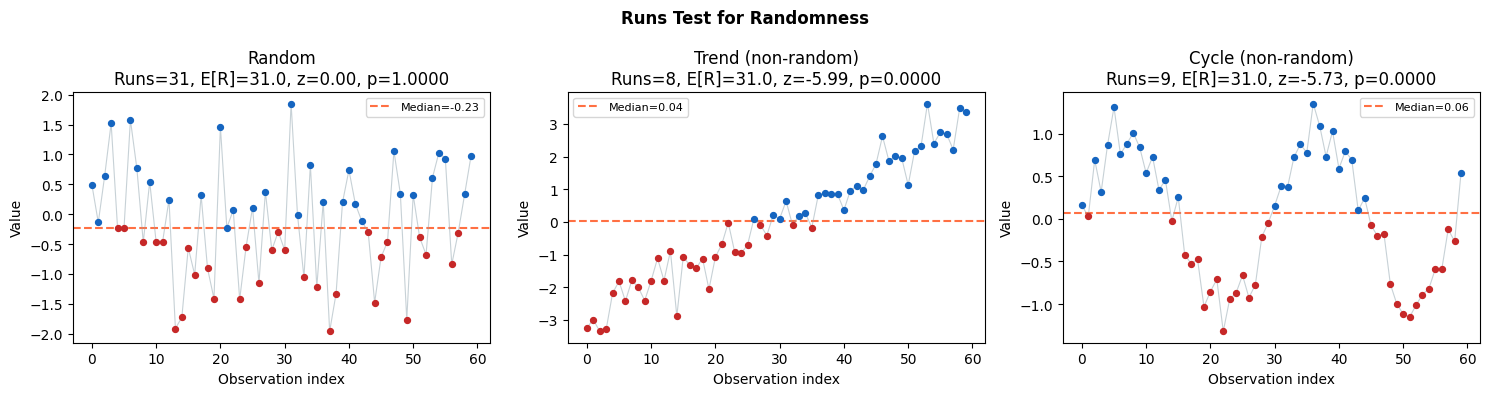

Random    : runs=31, E[R]=31.0, z=0.00, p=1.0000 → Fail to reject H₀ (random)
Trend     : runs=8, E[R]=31.0, z=-5.99, p=0.0000 → Reject H₀ (non-random)
Cycle     : runs=9, E[R]=31.0, z=-5.73, p=0.0000 → Reject H₀ (non-random)


In [2]:
def runs_test(x):
    median = np.median(x)
    above = (x > median).astype(int)
    n = len(above)
    n1 = above.sum()   # above median
    n2 = n - n1        # below median
    runs = 1 + np.sum(above[:-1] != above[1:])
    E_R = 2*n1*n2 / (n1+n2) + 1
    Var_R = 2*n1*n2*(2*n1*n2 - n) / (n**2 * (n-1))
    z = (runs - E_R) / np.sqrt(Var_R)
    p = 2 * stats.norm.sf(abs(z))
    return runs, E_R, z, p

np.random.seed(42)
n = 60
x_random = np.random.normal(0, 1, n)
x_trend   = np.linspace(-3, 3, n) + np.random.normal(0, 0.5, n)
x_cycle   = np.sin(np.linspace(0, 4*np.pi, n)) + np.random.normal(0, 0.2, n)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Runs Test for Randomness', fontsize=12, fontweight='bold')

for ax, x, title_base in zip(axes, [x_random, x_trend, x_cycle],
                               ['Random', 'Trend (non-random)', 'Cycle (non-random)']):
    runs, E_R, z, p = runs_test(x)
    median = np.median(x)
    above = x > median
    ax.axhline(median, color='#FF7043', lw=1.5, ls='--', label=f'Median={median:.2f}')
    # Colour by above/below median
    for i in range(len(x)):
        color = '#1565C0' if above[i] else '#C62828'
        ax.scatter(i, x[i], color=color, s=18, zorder=3)
    ax.plot(range(len(x)), x, color='#90A4AE', lw=0.8, alpha=0.5)
    ax.set_title(f'{title_base}\nRuns={runs:.0f}, E[R]={E_R:.1f}, z={z:.2f}, p={p:.4f}')
    ax.set_xlabel('Observation index'); ax.set_ylabel('Value')
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

for x, name in [(x_random, 'Random'), (x_trend, 'Trend'), (x_cycle, 'Cycle')]:
    runs, E_R, z, p = runs_test(x)
    decision = 'Reject H₀ (non-random)' if p < 0.05 else 'Fail to reject H₀ (random)'
    print(f'{name:10s}: runs={runs:.0f}, E[R]={E_R:.1f}, z={z:.2f}, p={p:.4f} → {decision}')

## Key Takeaways

| | |
|---|---|
| **Too few runs** | Trend or autocorrelation — consecutive values are similar |
| **Too many runs** | Alternating pattern — systematic oscillation |
| **Expected runs** | ~n/2 for a truly random sequence |
| **Complements lag plot** | Runs test quantifies what the lag plot shows visually |
| **Limitation** | Only tests above/below median — misses variance changes |
| **Use in EDA** | Run before any modelling; non-random data violates iid assumption |